# LLM Data Preprocessing: Preparing Text for Language Model Training

Self-Attention explains how tokens interact with each other, but before a Transformer can process tokens, raw text must be converted into a clean numerical format.

This notebook starts the LLM section by focusing on the data preparation steps that happen before model training: cleaning, normalization, tokenization, chunking, padding, and building input-target pairs for language modeling.

## Introduction

Large Language Models do not understand raw text directly. A model receives numbers, not sentences. Before text reaches a Transformer block, it must be converted into token IDs and arranged into fixed-shape training batches.

Preprocessing is not just a technical setup step. The quality of the data pipeline strongly affects model quality. Noisy data can produce noisy behavior, duplicated samples can encourage memorization, and poor tokenization or chunking can make training less efficient.

## Where Data Preprocessing Fits in the LLM Pipeline

A simplified language model training pipeline looks like this:

Raw Text → Cleaning → Normalization → Tokenization → Chunking → Input IDs → Training Batches → Language Model

In [1]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

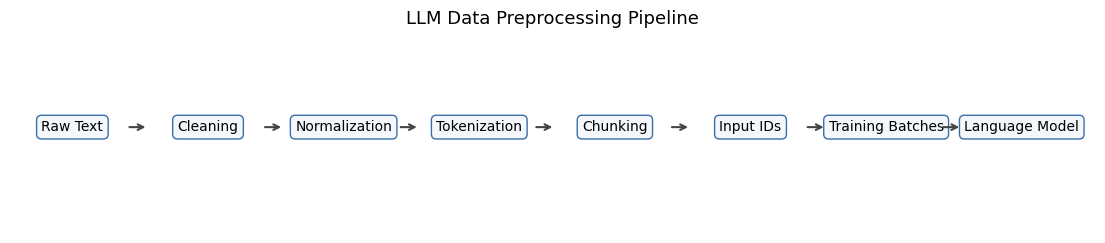

In [2]:
pipeline_steps = [
    "Raw Text",
    "Cleaning",
    "Normalization",
    "Tokenization",
    "Chunking",
    "Input IDs",
    "Training Batches",
    "Language Model",
]

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.set_xlim(0, len(pipeline_steps))
ax.set_ylim(0, 1)
ax.axis("off")

for idx, step in enumerate(pipeline_steps):
    x = idx + 0.08
    ax.text(
        x + 0.38,
        0.55,
        step,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f4f7fb", edgecolor="#3b6ea8"),
    )
    if idx < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(idx + 1.02, 0.55),
            xytext=(idx + 0.86, 0.55),
            arrowprops=dict(arrowstyle="->", color="#444444", lw=1.5),
        )

ax.set_title("LLM Data Preprocessing Pipeline", fontsize=13, pad=12)
plt.show()

## Raw Text Dataset

The dataset below is synthetic, but it is designed to look like real raw text collected from product logs, support tickets, documentation, reviews, and domain-specific notes.

It intentionally includes noise: extra spaces, mixed casing, URLs, emails, numbers, repeated punctuation, special characters, and duplicate lines.

In [3]:
raw_samples = [
    "  Our AI assistant reduced ticket response time by 34% in Q4!!!  ",
    "Payment failed for invoice #INV-2048, please contact billing@example.com.",
    "Read the API docs at https://docs.example.com/v2/auth before deploying.",
    "Patient reports mild headache; follow-up scheduled for 03/18/2026.",
    "STUDENTS can submit assignments via the portal until 11:59 PM.",
    "Login alerts detected from unusual IPs: 192.168.1.45 and 10.0.0.8!!!",
    "The headphones sound great, but the charging case scratches easily...",
    "  The new dashboard loads   slowly after the latest release. ",
    "Reset password link sent to user.name+trial@example.org",
    "Quarterly revenue increased from $1.2M to $1.5M; margin stayed flat.",
    "Endpoint /users/{id}/permissions returns 403 for admin accounts.",
    "Excelente soporte, but the app crashes on older Android devices.",
    "CPU usage spikes to 98% when batch_size=64 and sequence_length=4096.",
    "Please update the README: setup requires Python 3.11, not 3.9.",
    "Patient ID 55219 has lab values outside the expected range.",
    "FREE trial!!! Visit http://promo.example.net now $$$",
    "The model summary shows 125,000,000 parameters and 12 attention heads.",
    "Refund request duplicated duplicated duplicated in the support queue.",
    "SSH login blocked after 5 failed attempts; investigate immediately.",
    "Documentation says use --force, but production scripts should avoid it.",
    "The new dashboard loads   slowly after the latest release.",
    "Shipment arrived two days late; packaging was damaged :( ",
    "Data export CSV contains null values, commas, and weird symbols ###",
    "Legal review: retain clause 4.2 exactly as written; do not lowercase names.",
    "Contact Security-Team@Example.COM if suspicious OAuth consent appears.",
]

raw_df = pd.DataFrame({"raw_text": raw_samples})
raw_df["raw_char_length"] = raw_df["raw_text"].str.len()
display(raw_df)

,raw_text,raw_char_length
0,Our AI assistant reduced ticket response tim...,65
1,"Payment failed for invoice #INV-2048, please c...",73
2,Read the API docs at https://docs.example.com/...,71
3,Patient reports mild headache; follow-up sched...,66
4,STUDENTS can submit assignments via the portal...,62
5,Login alerts detected from unusual IPs: 192.16...,68
6,"The headphones sound great, but the charging c...",69
7,The new dashboard loads slowly after the l...,61
8,Reset password link sent to user.name+trial@ex...,55
9,Quarterly revenue increased from $1.2M to $1.5...,68


## Basic Text Cleaning

Basic cleaning makes the text more consistent while preserving the information needed for learning. In practice, the exact cleaning rules depend on the model objective and the domain.

The functions below handle common noise:

- extra whitespace
- mixed casing
- URLs
- email addresses
- repeated punctuation
- duplicate samples

In [4]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[\w.+-]+@[\w-]+(?:\.[\w-]+)+\b", flags=re.IGNORECASE)
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1+")
WHITESPACE_PATTERN = re.compile(r"\s+")

def normalize_whitespace(text):
    """Collapse repeated whitespace and trim leading/trailing spaces."""
    return WHITESPACE_PATTERN.sub(" ", text).strip()


def mask_urls(text, token="<URL>"):
    """Replace URLs with a placeholder token."""
    return URL_PATTERN.sub(token, text)


def mask_emails(text, token="<EMAIL>"):
    """Replace email addresses with a placeholder token."""
    return EMAIL_PATTERN.sub(token, text)


def reduce_repeated_punctuation(text):
    """Reduce repeated punctuation such as !!! or ... to a single mark."""
    return REPEATED_PUNCT_PATTERN.sub(r"\1", text)


def clean_text(text, lowercase=True):
    """Apply a lightweight cleaning pipeline to one text sample."""
    text = mask_urls(text)
    text = mask_emails(text)
    text = reduce_repeated_punctuation(text)
    text = normalize_whitespace(text)
    if lowercase:
        text = text.lower()
    return text


def clean_and_deduplicate(texts):
    """Clean a list of texts and remove exact duplicates after cleaning."""
    cleaned = [clean_text(text) for text in texts]
    return list(dict.fromkeys(cleaned))

In [5]:
cleaning_preview = pd.DataFrame({
    "before": raw_df["raw_text"],
    "after": [clean_text(text) for text in raw_df["raw_text"]],
})

display(cleaning_preview.head(10))

,before,after
0,Our AI assistant reduced ticket response tim...,our ai assistant reduced ticket response time ...
1,"Payment failed for invoice #INV-2048, please c...","payment failed for invoice #inv-2048, please c..."
2,Read the API docs at https://docs.example.com/...,read the api docs at <url> before deploying.
3,Patient reports mild headache; follow-up sched...,patient reports mild headache; follow-up sched...
4,STUDENTS can submit assignments via the portal...,students can submit assignments via the portal...
5,Login alerts detected from unusual IPs: 192.16...,login alerts detected from unusual ips: 192.16...
6,"The headphones sound great, but the charging c...","the headphones sound great, but the charging c..."
7,The new dashboard loads slowly after the l...,the new dashboard loads slowly after the lates...
8,Reset password link sent to user.name+trial@ex...,reset password link sent to <email>
9,Quarterly revenue increased from $1.2M to $1.5...,quarterly revenue increased from $1.2m to $1.5...


In [6]:
cleaned_texts = clean_and_deduplicate(raw_samples)
cleaned_df = pd.DataFrame({"cleaned_text": cleaned_texts})
cleaned_df["cleaned_char_length"] = cleaned_df["cleaned_text"].str.len()

print(f"Raw samples: {len(raw_samples)}")
print(f"Cleaned unique samples: {len(cleaned_texts)}")
display(cleaned_df.head(10))

Raw samples: 25
Cleaned unique samples: 24


,cleaned_text,cleaned_char_length
0,our ai assistant reduced ticket response time ...,59
1,"payment failed for invoice #inv-2048, please c...",61
2,read the api docs at <url> before deploying.,44
3,patient reports mild headache; follow-up sched...,66
4,students can submit assignments via the portal...,62
5,login alerts detected from unusual ips: 192.16...,66
6,"the headphones sound great, but the charging c...",67
7,the new dashboard loads slowly after the lates...,56
8,reset password link sent to <email>,35
9,quarterly revenue increased from $1.2m to $1.5...,68


## Text Normalization

Normalization converts text into a more consistent representation. Lowercasing and whitespace normalization are common examples.

However, aggressive cleaning can remove useful information. Code snippets may rely on case-sensitive names, legal documents may require exact wording, medical notes may include important abbreviations, and financial text often depends on numbers, symbols, and dates. A good preprocessing pipeline should preserve what the model needs to learn.

In [7]:
normalization_examples = [
    "Function getUserID() differs from get_user_id().",
    "Clause 4.2 must remain EXACTLY as written.",
    "Patient has HbA1c of 7.8% and BP 140/90.",
    "Revenue grew from $1.2M to $1.5M in Q4.",
]

normalization_df = pd.DataFrame({
    "original": normalization_examples,
    "normalized": [clean_text(text) for text in normalization_examples],
})

display(normalization_df)

,original,normalized
0,Function getUserID() differs from get_user_id().,function getuserid() differs from get_user_id().
1,Clause 4.2 must remain EXACTLY as written.,clause 4.2 must remain exactly as written.
2,Patient has HbA1c of 7.8% and BP 140/90.,patient has hba1c of 7.8% and bp 140/90.
3,Revenue grew from $1.2M to $1.5M in Q4.,revenue grew from $1.2m to $1.5m in q4.


## Tokenization

A token is a unit of text used by a model. Depending on the tokenizer, a token may be a word, a subword, a character, a byte, or a special symbol.

A tokenizer maps text into token IDs using a vocabulary. The model learns from those IDs, not from raw strings.

In [8]:
def whitespace_tokenize(text):
    """Split text into tokens using whitespace."""
    return text.split()


def build_vocabulary(texts, min_frequency=1, special_tokens=None):
    """Build token-to-id and id-to-token mappings from tokenized texts."""
    if special_tokens is None:
        special_tokens = ["<PAD>", "<UNK>"]

    token_counts = Counter()
    for text in texts:
        token_counts.update(whitespace_tokenize(text))

    vocabulary = list(special_tokens)
    vocabulary.extend(
        token for token, count in token_counts.most_common()
        if count >= min_frequency and token not in special_tokens
    )

    token_to_id = {token: idx for idx, token in enumerate(vocabulary)}
    id_to_token = {idx: token for token, idx in token_to_id.items()}
    return token_to_id, id_to_token, token_counts


def encode_tokens(tokens, token_to_id):
    """Convert tokens into integer IDs."""
    unk_id = token_to_id["<UNK>"]
    return [token_to_id.get(token, unk_id) for token in tokens]


def decode_ids(token_ids, id_to_token):
    """Convert integer IDs back into tokens."""
    return [id_to_token.get(token_id, "<UNK>") for token_id in token_ids]

In [9]:
token_to_id, id_to_token, token_counts = build_vocabulary(cleaned_texts)

print(f"Vocabulary size: {len(token_to_id)}")
print("First 20 vocabulary items:")
display(pd.DataFrame(list(token_to_id.items())[:20], columns=["token", "id"]))

Vocabulary size: 188
First 20 vocabulary items:


,token,id
0,<PAD>,0
1,<UNK>,1
2,the,2
3,and,3
4,for,4
5,but,5
6,to,6
7,duplicated,7
8,in,8
9,failed,9


In [10]:
example_text = cleaned_texts[0]
example_tokens = whitespace_tokenize(example_text)
example_ids = encode_tokens(example_tokens, token_to_id)

print("Text:", example_text)
print("Tokens:", example_tokens)
print("Token IDs:", example_ids)
print("Decoded:", " ".join(decode_ids(example_ids, id_to_token)))

Text: our ai assistant reduced ticket response time by 34% in q4!
Tokens: ['our', 'ai', 'assistant', 'reduced', 'ticket', 'response', 'time', 'by', '34%', 'in', 'q4!']
Token IDs: [19, 20, 21, 22, 23, 24, 25, 26, 27, 8, 28]
Decoded: our ai assistant reduced ticket response time by 34% in q4!


## Subword Tokenization Intuition

Whitespace tokenization is easy to understand, but it is too limited for modern LLMs.

Problems include:

- out-of-vocabulary words
- rare domain terms
- multilingual text
- misspellings
- technical identifiers such as `sequence_length=4096`

Modern tokenizers often use subword methods. Byte Pair Encoding, WordPiece, and SentencePiece split text into reusable pieces. This helps represent rare words and technical terms without needing a vocabulary entry for every complete word.

In [11]:
subword_examples = [
    "tokenization",
    "cybersecurity",
    "multilingual",
    "sequence_length=4096",
]

subword_demo = pd.DataFrame({
    "word_or_term": subword_examples,
    "possible_subword_intuition": [
        "token + ization",
        "cyber + security",
        "multi + lingual",
        "sequence + _ + length + = + 4096",
    ],
})

display(subword_demo)

,word_or_term,possible_subword_intuition
0,tokenization,token + ization
1,cybersecurity,cyber + security
2,multilingual,multi + lingual
3,sequence_length=4096,sequence + _ + length + = + 4096


## Using a Real Tokenizer

The educational tokenizer above shows the core idea, but production LLM workflows use trained tokenizers.

The next cell tries to use a Hugging Face tokenizer. If `transformers` or the tokenizer files are not available locally, the notebook continues and prints an installation note.

```bash
pip install transformers
```

In [12]:
sample_tokenizer_texts = [
    "Self-attention connects tokens before the Transformer predicts the next token.",
    "Contact Security-Team@Example.COM if suspicious OAuth consent appears.",
    "CPU usage spikes when sequence_length=4096.",
]

try:
    from transformers import AutoTokenizer

    hf_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)
    tokenizer_rows = []

    for text in sample_tokenizer_texts:
        encoded = hf_tokenizer(text)
        token_ids = encoded["input_ids"]
        tokens = hf_tokenizer.convert_ids_to_tokens(token_ids)
        decoded = hf_tokenizer.decode(token_ids)
        tokenizer_rows.append({
            "original_text": text,
            "tokens": tokens,
            "token_ids": token_ids,
            "decoded_text": decoded,
        })

    display(pd.DataFrame(tokenizer_rows))

except ImportError:
    print("transformers is not installed. To try this section, run: pip install transformers")
except OSError:
    print(
        "transformers is installed, but bert-base-uncased is not available locally. "
        "Download it in an online environment or remove local_files_only=True."
    )

/Users/mihrinur/.pyenv/versions/3.11.6/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers is installed, but bert-base-uncased is not available locally. Download it in an online environment or remove local_files_only=True.


## Sequence Length and Chunking

LLMs have context window limits. If a document is longer than the maximum sequence length, it must be split into smaller chunks.

Chunk size controls how much context each training example contains. Overlap can preserve continuity between neighboring chunks, but too much overlap increases duplication.

In [13]:
def chunk_sequence(sequence, chunk_size, overlap=0):
    """Split a sequence into fixed-size chunks with optional overlap."""
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    if overlap < 0:
        raise ValueError("overlap cannot be negative")
    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size")

    step = chunk_size - overlap
    return [sequence[start:start + chunk_size] for start in range(0, len(sequence), step)]


def chunk_text_tokens(text, chunk_size=8, overlap=2):
    """Tokenize text with whitespace and return overlapping token chunks."""
    tokens = whitespace_tokenize(text)
    return chunk_sequence(tokens, chunk_size=chunk_size, overlap=overlap)

In [14]:
long_example = (
    "before a transformer can learn language patterns raw text is cleaned normalized "
    "tokenized chunked converted into ids and arranged into training batches"
)

chunks = chunk_text_tokens(long_example, chunk_size=8, overlap=2)
chunk_df = pd.DataFrame({
    "chunk_id": range(len(chunks)),
    "tokens": chunks,
    "token_count": [len(chunk) for chunk in chunks],
})

display(chunk_df)

,chunk_id,tokens,token_count
0,0,"[before, a, transformer, can, learn, language,...",8
1,1,"[patterns, raw, text, is, cleaned, normalized,...",8
2,2,"[tokenized, chunked, converted, into, ids, and...",8
3,3,"[arranged, into, training, batches]",4


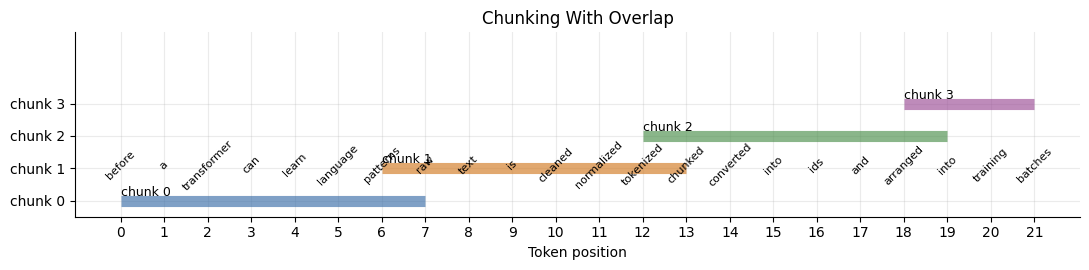

In [15]:
fig, ax = plt.subplots(figsize=(11, 2.8))
tokens = whitespace_tokenize(long_example)

for token_idx, token in enumerate(tokens):
    ax.text(token_idx, 1.1, token, ha="center", va="center", rotation=45, fontsize=8)

colors = ["#3b6ea8", "#d17a22", "#4b8f4b", "#9b4d96"]
for chunk_idx, chunk in enumerate(chunks):
    start = chunk_idx * (8 - 2)
    end = start + len(chunk) - 1
    ax.hlines(chunk_idx, start, end, lw=8, color=colors[chunk_idx % len(colors)], alpha=0.65)
    ax.text(start, chunk_idx + 0.15, f"chunk {chunk_idx}", fontsize=9)

ax.set_yticks(range(len(chunks)))
ax.set_yticklabels([f"chunk {i}" for i in range(len(chunks))])
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(range(len(tokens)))
ax.set_title("Chunking With Overlap")
ax.set_xlabel("Token position")
ax.set_ylim(-0.5, len(chunks) + 1.2)
plt.tight_layout()
plt.show()

## Creating Input and Target Sequences

A common language modeling objective is next-token prediction.

Input:

`The model learns from`

Target:

`model learns from data`

The target is the input shifted one token to the left. At each position, the model learns to predict the next token.

In [16]:
def create_input_target_pairs(token_ids, sequence_length):
    """Create next-token prediction input and target sequences."""
    pairs = []
    for start in range(0, len(token_ids) - sequence_length):
        window = token_ids[start:start + sequence_length + 1]
        pairs.append({
            "input_ids": window[:-1],
            "target_ids": window[1:],
        })
    return pairs

simple_sentence = "the model learns from data"
simple_tokens = whitespace_tokenize(simple_sentence)
simple_token_to_id = {token: idx for idx, token in enumerate(simple_tokens)}
simple_ids = [simple_token_to_id[token] for token in simple_tokens]

pair = create_input_target_pairs(simple_ids, sequence_length=4)[0]
pair_preview = pd.DataFrame({
    "input_tokens": [simple_tokens[:-1]],
    "input_ids": [pair["input_ids"]],
    "target_tokens": [simple_tokens[1:]],
    "target_ids": [pair["target_ids"]],
})

display(pair_preview)

,input_tokens,input_ids,target_tokens,target_ids
0,"[the, model, learns, from]","[0, 1, 2, 3]","[model, learns, from, data]","[1, 2, 3, 4]"


## Padding and Truncation

Training batches need equal sequence lengths so tensors can be stacked efficiently.

- Padding adds a special token to shorter sequences.
- Truncation cuts sequences that are too long.
- Attention masks mark real tokens with `1` and padding tokens with `0`.

In [17]:
def pad_or_truncate(token_ids, max_length, pad_id=0):
    """Pad or truncate token IDs and create an attention mask."""
    truncated = token_ids[:max_length]
    attention_mask = [1] * len(truncated)

    padding_needed = max_length - len(truncated)
    if padding_needed > 0:
        truncated = truncated + [pad_id] * padding_needed
        attention_mask = attention_mask + [0] * padding_needed

    return truncated, attention_mask

batch_examples = [
    encode_tokens(whitespace_tokenize(cleaned_texts[0]), token_to_id),
    encode_tokens(whitespace_tokenize(cleaned_texts[4]), token_to_id),
    encode_tokens(whitespace_tokenize(cleaned_texts[12]), token_to_id),
]

padding_rows = []
for ids in batch_examples:
    padded_ids, attention_mask = pad_or_truncate(ids, max_length=10, pad_id=token_to_id["<PAD>"])
    padding_rows.append({
        "original_length": len(ids),
        "padded_or_truncated_ids": padded_ids,
        "attention_mask": attention_mask,
    })

padding_df = pd.DataFrame(padding_rows)
display(padding_df)

,original_length,padded_or_truncated_ids,attention_mask
0,11,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 8]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,10,"[45, 46, 47, 48, 49, 2, 50, 51, 52, 53]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,9,"[99, 100, 101, 6, 102, 103, 104, 3, 105, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]"


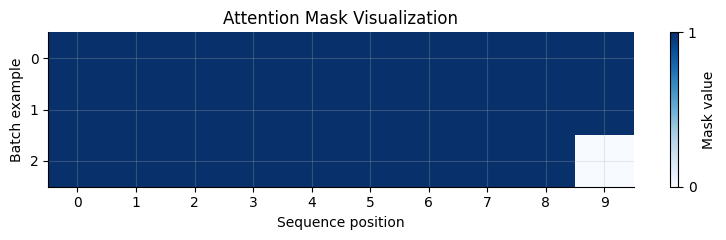

In [18]:
mask_matrix = np.array(padding_df["attention_mask"].tolist())

fig, ax = plt.subplots(figsize=(8, 2.5))
im = ax.imshow(mask_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_title("Attention Mask Visualization")
ax.set_xlabel("Sequence position")
ax.set_ylabel("Batch example")
ax.set_xticks(range(mask_matrix.shape[1]))
ax.set_yticks(range(mask_matrix.shape[0]))
fig.colorbar(im, ax=ax, ticks=[0, 1], label="Mask value")
plt.tight_layout()
plt.show()

## Mini Project: A Small LLM Preprocessing Pipeline

The function below combines the main ideas from the notebook into one lightweight pipeline.

It performs cleaning, deduplication, tokenization, chunking, input-target pair generation, padding, and attention mask creation. The result is a DataFrame suitable for inspection before turning data into tensors.

In [19]:
def prepare_llm_dataset(texts, chunk_size=12, overlap=3, max_length=10):
    """Prepare cleaned language modeling examples from raw text samples.

    Parameters
    ----------
    texts : list[str]
        Raw text samples.
    chunk_size : int
        Number of tokens per chunk before input-target splitting.
    overlap : int
        Number of tokens repeated between adjacent chunks.
    max_length : int
        Fixed length for padded input and target sequences.

    Returns
    -------
    pandas.DataFrame
        Prepared examples with tokens, IDs, targets, masks, and lengths.
    """
    cleaned_unique_texts = clean_and_deduplicate(texts)
    local_token_to_id, local_id_to_token, _ = build_vocabulary(cleaned_unique_texts)

    rows = []
    for cleaned_text in cleaned_unique_texts:
        tokens = whitespace_tokenize(cleaned_text)
        token_chunks = chunk_sequence(tokens, chunk_size=chunk_size, overlap=overlap)

        for chunk in token_chunks:
            if len(chunk) < 2:
                continue

            chunk_ids = encode_tokens(chunk, local_token_to_id)
            input_ids = chunk_ids[:-1]
            target_ids = chunk_ids[1:]
            padded_input_ids, attention_mask = pad_or_truncate(
                input_ids,
                max_length=max_length,
                pad_id=local_token_to_id["<PAD>"],
            )
            padded_target_ids, _ = pad_or_truncate(
                target_ids,
                max_length=max_length,
                pad_id=local_token_to_id["<PAD>"],
            )

            rows.append({
                "cleaned_text": cleaned_text,
                "tokens": chunk,
                "input_ids": padded_input_ids,
                "target_ids": padded_target_ids,
                "attention_mask": attention_mask,
                "sequence_length": min(len(input_ids), max_length),
            })

    return pd.DataFrame(rows), local_token_to_id, local_id_to_token

In [20]:
prepared_df, pipeline_token_to_id, pipeline_id_to_token = prepare_llm_dataset(
    raw_samples,
    chunk_size=12,
    overlap=3,
    max_length=10,
)

print(f"Prepared training examples: {len(prepared_df)}")
display(prepared_df.head(10))

Prepared training examples: 27


,cleaned_text,tokens,input_ids,target_ids,attention_mask,sequence_length
0,our ai assistant reduced ticket response time ...,"[our, ai, assistant, reduced, ticket, response...","[19, 20, 21, 22, 23, 24, 25, 26, 27, 8]","[20, 21, 22, 23, 24, 25, 26, 27, 8, 28]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",10
1,our ai assistant reduced ticket response time ...,"[in, q4!]","[8, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[28, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1
2,"payment failed for invoice #inv-2048, please c...","[payment, failed, for, invoice, #inv-2048,, pl...","[29, 9, 4, 30, 31, 10, 11, 0, 0, 0]","[9, 4, 30, 31, 10, 11, 32, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]",7
3,read the api docs at <url> before deploying.,"[read, the, api, docs, at, <url>, before, depl...","[33, 2, 34, 35, 36, 12, 37, 0, 0, 0]","[2, 34, 35, 36, 12, 37, 38, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]",7
4,patient reports mild headache; follow-up sched...,"[patient, reports, mild, headache;, follow-up,...","[13, 39, 40, 41, 42, 43, 4, 0, 0, 0]","[39, 40, 41, 42, 43, 4, 44, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]",7
5,students can submit assignments via the portal...,"[students, can, submit, assignments, via, the,...","[45, 46, 47, 48, 49, 2, 50, 51, 52, 0]","[46, 47, 48, 49, 2, 50, 51, 52, 53, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",9
6,login alerts detected from unusual ips: 192.16...,"[login, alerts, detected, from, unusual, ips:,...","[14, 54, 55, 15, 56, 57, 58, 3, 0, 0]","[54, 55, 15, 56, 57, 58, 3, 59, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0]",8
7,"the headphones sound great, but the charging c...","[the, headphones, sound, great,, but, the, cha...","[2, 60, 61, 62, 5, 2, 63, 64, 65, 0]","[60, 61, 62, 5, 2, 63, 64, 65, 66, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]",9
8,the new dashboard loads slowly after the lates...,"[the, new, dashboard, loads, slowly, after, th...","[2, 67, 68, 69, 70, 16, 2, 71, 0, 0]","[67, 68, 69, 70, 16, 2, 71, 72, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0]",8
9,reset password link sent to <email>,"[reset, password, link, sent, to, <email>]","[73, 74, 75, 76, 6, 0, 0, 0, 0, 0]","[74, 75, 76, 6, 17, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]",5


## Visualizations

Visual inspection helps catch preprocessing issues early. The plots below compare raw and cleaned text lengths, token counts, vocabulary frequency, chunking behavior, and padding masks.

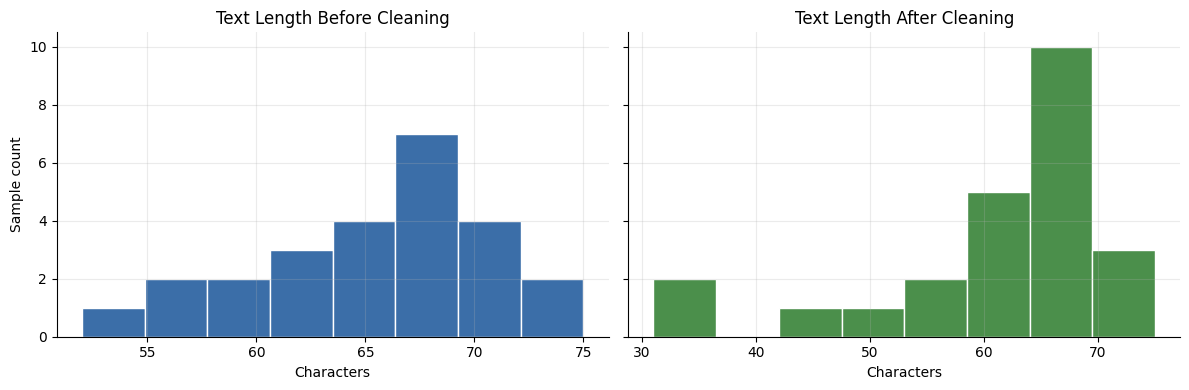

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(raw_df["raw_char_length"], bins=8, color="#3b6ea8", edgecolor="white")
axes[0].set_title("Text Length Before Cleaning")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Sample count")

axes[1].hist(cleaned_df["cleaned_char_length"], bins=8, color="#4b8f4b", edgecolor="white")
axes[1].set_title("Text Length After Cleaning")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

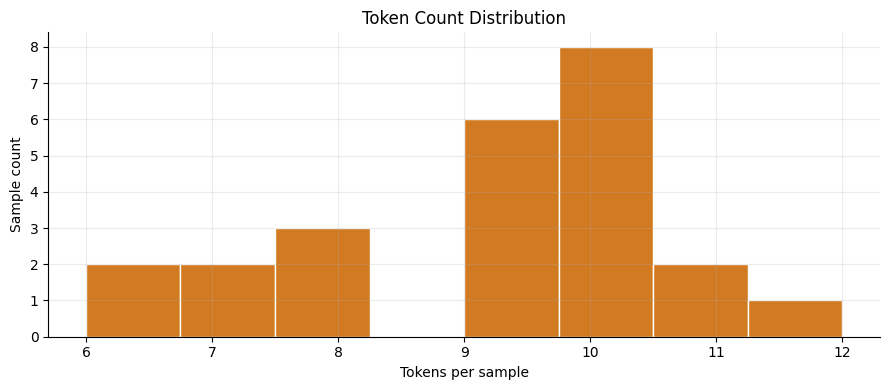

In [22]:
cleaned_df["token_count"] = cleaned_df["cleaned_text"].apply(lambda text: len(whitespace_tokenize(text)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cleaned_df["token_count"], bins=8, color="#d17a22", edgecolor="white")
ax.set_title("Token Count Distribution")
ax.set_xlabel("Tokens per sample")
ax.set_ylabel("Sample count")
plt.tight_layout()
plt.show()

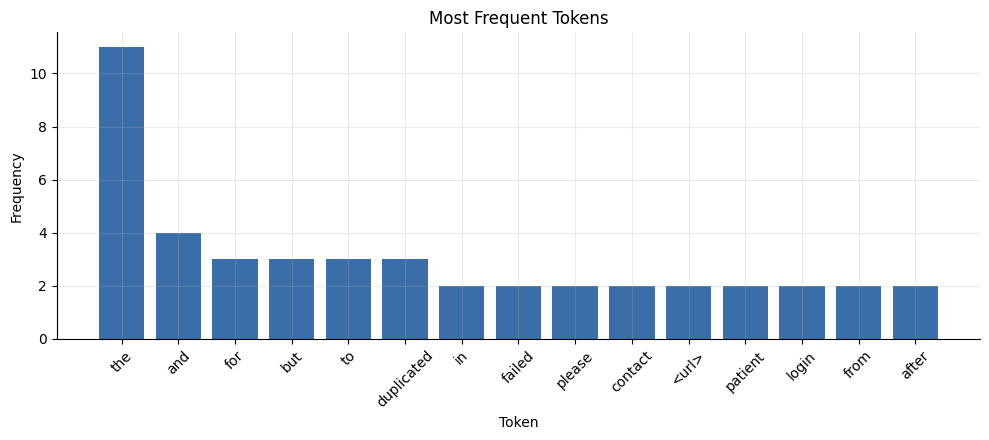

In [23]:
top_tokens = pd.DataFrame(token_counts.most_common(15), columns=["token", "frequency"])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(top_tokens["token"], top_tokens["frequency"], color="#3b6ea8")
ax.set_title("Most Frequent Tokens")
ax.set_xlabel("Token")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

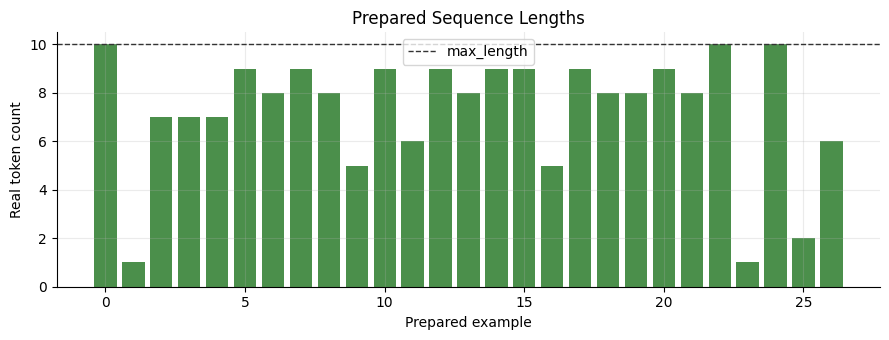

In [24]:
sequence_lengths = prepared_df["sequence_length"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(sequence_lengths)), sequence_lengths, color="#4b8f4b")
ax.axhline(10, color="#333333", linestyle="--", linewidth=1, label="max_length")
ax.set_title("Prepared Sequence Lengths")
ax.set_xlabel("Prepared example")
ax.set_ylabel("Real token count")
ax.legend()
plt.tight_layout()
plt.show()

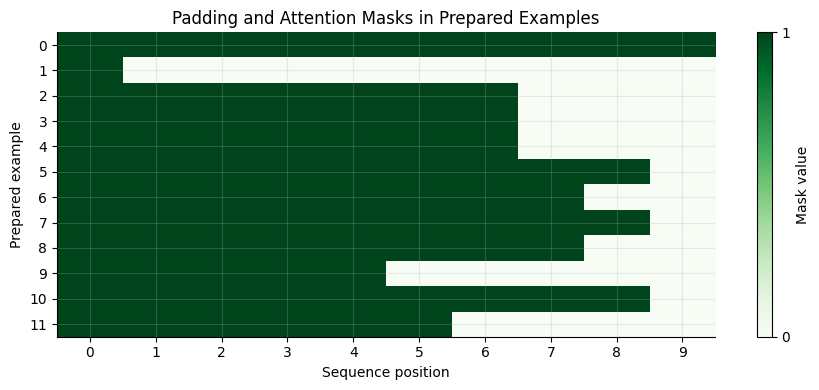

In [25]:
padding_matrix = np.array(prepared_df.head(12)["attention_mask"].tolist())

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(padding_matrix, aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_title("Padding and Attention Masks in Prepared Examples")
ax.set_xlabel("Sequence position")
ax.set_ylabel("Prepared example")
ax.set_xticks(range(padding_matrix.shape[1]))
ax.set_yticks(range(padding_matrix.shape[0]))
fig.colorbar(im, ax=ax, ticks=[0, 1], label="Mask value")
plt.tight_layout()
plt.show()

## Common Preprocessing Mistakes

Common mistakes include:

- removing too much information during cleaning
- skipping deduplication
- choosing a chunk size that breaks important context
- ignoring domain-specific tokens
- leaking evaluation data into training data
- mixing high-quality and low-quality sources without filtering

These issues can quietly reduce model quality even when the model architecture is strong.

## Why Data Quality Matters for LLMs

Data quality shapes model behavior.

Noisy data can create noisy outputs. Duplicated data can increase memorization risk. Biased data can produce biased predictions. Bad tokenization can waste context length and compute. Poor chunking can split related information across examples, making it harder for the model to learn useful dependencies.

A clean preprocessing pipeline does not guarantee a good model, but a weak pipeline makes good results much harder.

## Final Summary

Key takeaways:

- LLMs require clean, tokenized text.
- Tokenization turns text into IDs.
- Chunking handles context window limits.
- Input-target pairs enable next-token prediction.
- Attention masks help models ignore padding.
- Preprocessing quality directly affects model quality.

## Next Notebook

➡️ Next: Transformer Architecture

The next notebook will move from preprocessing text to understanding the Transformer blocks that process token sequences.